In [91]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris,load_breast_cancer
import matplotlib.pyplot as plt


In [75]:
# X1,y1=load_iris(return_X_y=True)
# X2,y2=load_breast_cancer(return_X_y=True)
# X2
iris=load_iris()
cancer=load_breast_cancer()

In [76]:
X1=pd.DataFrame(iris['data'],columns=iris['feature_names'])
X2=pd.DataFrame(cancer['data'],columns=cancer['feature_names'])

In [77]:
y1=iris['target']
y2=cancer['target']

In [78]:
from sklearn.model_selection import train_test_split
X1_train,X1_test,y1_train,y1_test=train_test_split(X1,y1,test_size=0.3,random_state=42)
X2_train,X2_test,y2_train,y2_test=train_test_split(X2,y2,test_size=0.3,random_state=42)

In [79]:
from sklearn.preprocessing import StandardScaler
scaler1=StandardScaler()
X1_train_scaled=scaler1.fit_transform(X1_train)
X1_test_scaled=scaler1.transform(X1_test)



In [80]:

scaler2=StandardScaler()
X2_train_scaled=scaler2.fit_transform(X2_train)
X2_test_scaled=scaler2.transform(X2_test)

Text(0.5, 1.0, 'Decision Tree')

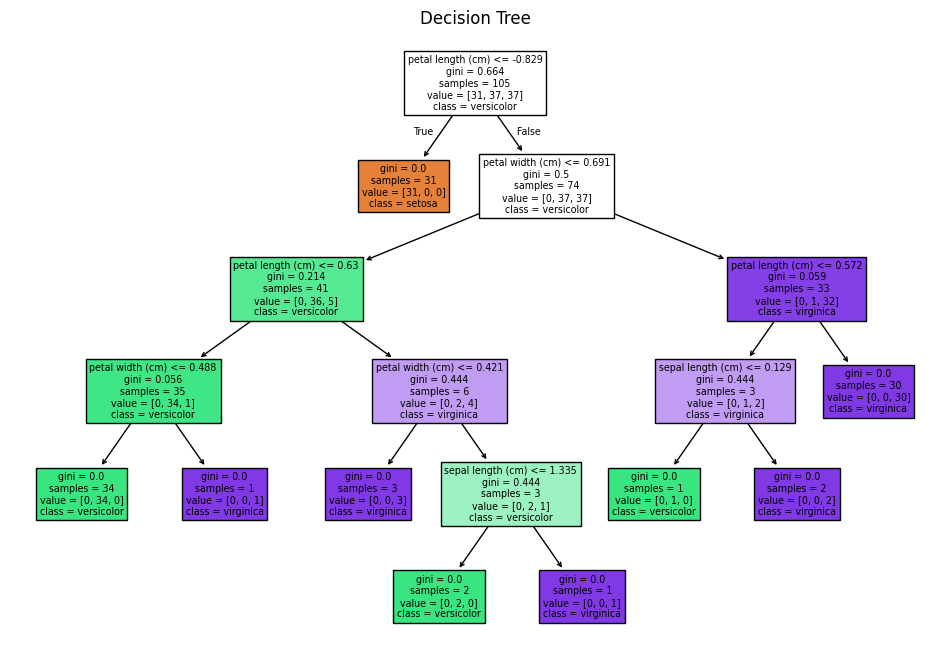

In [95]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
dtc=DecisionTreeClassifier()
dtc.fit(X1_train_scaled,y1_train)
plt.figure(figsize=(12,8))
tree.plot_tree(dtc,filled=True,feature_names=iris.feature_names,class_names=iris.target_names)
plt.title('Decision Tree')

In [81]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [82]:
models={
    'svc': SVC(kernel='rbf'),
    'nb': GaussianNB(),
    'dtc': DecisionTreeClassifier(),
    'ann': MLPClassifier(hidden_layer_sizes=(100,),solver='adam',max_iter=1000,random_state=42,activation='relu'),
    'knn':KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree'),
    'lr':LogisticRegression()
}

In [85]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
for name,model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    
    scores = cross_val_score(pipe, X1_train, y1_train, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean():.2f}")

    

svc: 0.94
nb: 0.93
dtc: 0.93
ann: 0.93
knn: 0.91
lr: 0.94


In [87]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
for name,model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    
    scores = cross_val_score(pipe, X2_train, y2_train, cv=5,scoring='accuracy')
    print(f"{name}: {scores.mean():.2f}")


svc: 0.96
nb: 0.93
dtc: 0.91
ann: 0.97
knn: 0.95
lr: 0.97
